# EDA — ZICER Hackathon Dataset

Four tables:
- **KLIJENTI** (~12k rows): client demographics
- **PROIZVODI** (~58k rows): products/accounts per client
- **STANJA PROIZVODA** (~818k rows): product balance snapshots
- **TRANSAKCIJE** (~1.19M rows): individual transactions

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_DIR = Path('dataRaw')

READ_KW = dict(sep=';', encoding='latin-1', low_memory=False)

## 1  Load data

In [5]:
clients   = pd.read_csv(DATA_DIR / 'HACKATHON ZICER 202604 KLIJENTI.csv',         **READ_KW)
products  = pd.read_csv(DATA_DIR / 'HACKATHON ZICER 202604 PROIZVODI.csv',        **READ_KW)
balances  = pd.read_csv(DATA_DIR / 'HACKATHON ZICER 202604 STANJA PROIZVODA.csv', **READ_KW)
txn       = pd.read_csv(DATA_DIR / 'HACKATHON ZICER 202604 TRANSAKCIJE.csv',      **READ_KW)

print('clients  :', clients.shape)
print('products :', products.shape)
print('balances :', balances.shape)
print('txn      :', txn.shape)

clients  : (11997, 38)
products : (58703, 13)
balances : (817933, 6)
txn      : (1187661, 10)


## 2  Column overview

In [6]:
for name, df in [('KLIJENTI', clients), ('PROIZVODI', products),
                 ('STANJA PROIZVODA', balances), ('TRANSAKCIJE', txn)]:
    print(f'\n── {name} ──')
    print(df.dtypes.to_string())


── KLIJENTI ──
IDENTIFIKATOR_KLIJENTA                     object
DOB                                         int64
GRAD_STALNE_ADRESE                         object
POSTANSKI_BROJ_STALNE_ADRESE               object
ZUPANIJA_STALNE_ADRESE                     object
DRZAVA_STALNE_ADRESE                       object
STATISTICKA_OZNAKA                         object
ORGANIZACIJSKA_JEDINICA_KLIJENTA            int64
DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA       object
DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA     object
SPOL                                       object
STATUS_ZAPOSLENJA                          object
VRSTA_ZAPOSLENJA                           object
POZICIJA                                   object
STRUCNA_SPREMA                             object
SIFRA_VRSTE_KLIJENTA                        int64
DRZAVA_NACIONALNOSTI                       object
GRAD_DOPISNE_ADRESE                        object
POSTANSKI_BROJ_DOPISNE_ADRESE              object
ZUPANIJA_DOPISNE_ADRESE           

## 3  Parse dates

In [ ]:
def parse_date(series, fmt='%d/%m/%Y/'):
    return pd.to_datetime(series.astype(str).str.strip(), format=fmt, errors='coerce')

# clients
clients['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA']   = parse_date(clients['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'])
clients['DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA'] = parse_date(clients['DATUM_ZADNJEG_POCETKA_POSLOVNOG_ODNOSA'])

# products
products['DATUM_OTVARANJA']   = parse_date(products['DATUM_OTVARANJA'])
products['DATUM_ZATVARANJA']  = parse_date(products['DATUM_ZATVARANJA'])

# balances
balances['VRIJEDI_OD'] = parse_date(balances['VRIJEDI_OD'])
balances['VRIJEDI_DO'] = parse_date(balances['VRIJEDI_DO'])

# transactions — strip the rogue "/" before the time: "8/5/2025/ 14:06:05" → "8/5/2025 14:06:05"
txn['DATUM_I_VRIJEME_TRANSAKCIJE'] = pd.to_datetime(
    txn['DATUM_I_VRIJEME_TRANSAKCIJE'].astype(str).str.strip().str.replace('/ ', ' ', regex=False),
    format='%d/%m/%Y %H:%M:%S', errors='coerce'
)
txn['TXN_DATE'] = txn['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.normalize()

# numeric
for col in ['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI']:
    txn[col] = pd.to_numeric(txn[col].astype(str).str.replace(',', '.'), errors='coerce')
for col in ['STANJE_U_DOMICILNOJ_VALUTI', 'STANJE_U_VALUTI']:
    balances[col] = pd.to_numeric(balances[col].astype(str).str.replace(',', '.'), errors='coerce')

print('Date parsing done.')
print('Parsed sample:', txn['DATUM_I_VRIJEME_TRANSAKCIJE'].dropna().iloc[0])
print('Null datetimes:', txn['DATUM_I_VRIJEME_TRANSAKCIJE'].isna().sum())

## 4  Missing-value heatmap

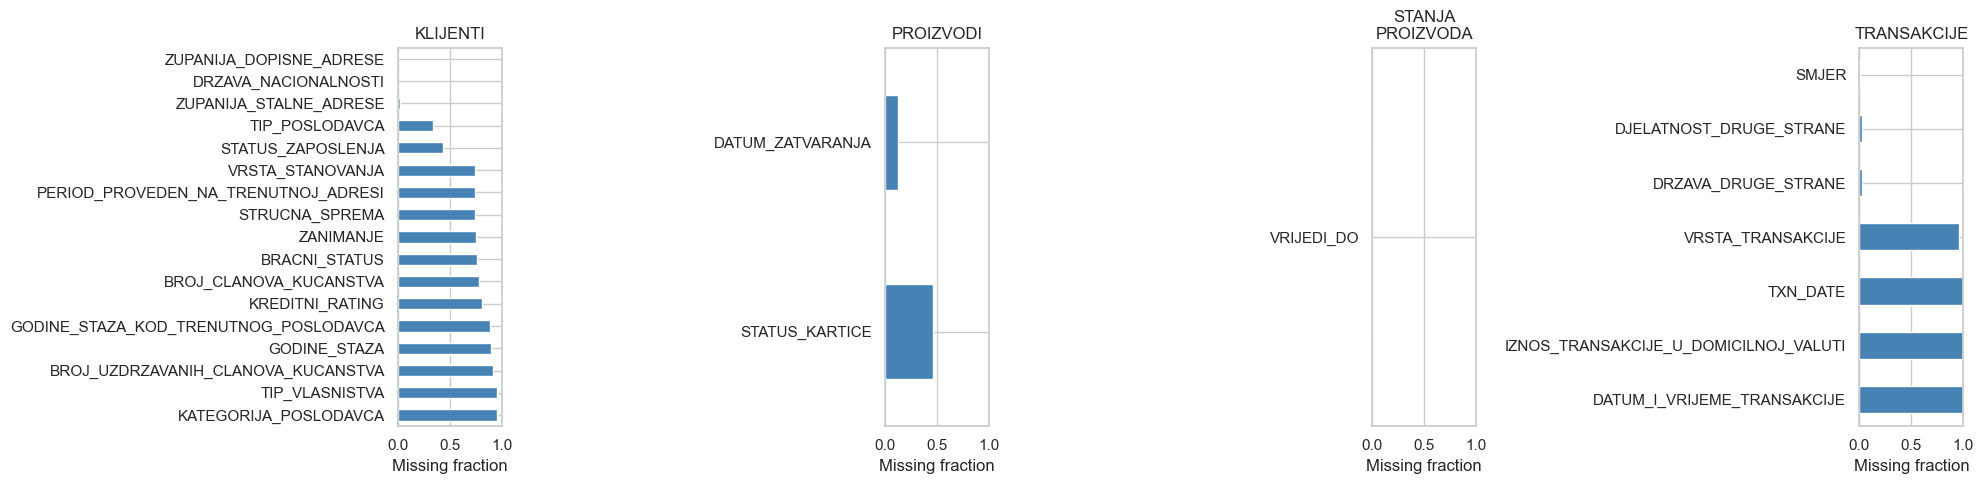

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datasets = [('KLIJENTI', clients), ('PROIZVODI', products),
            ('STANJA\nPROIZVODA', balances), ('TRANSAKCIJE', txn)]

for ax, (name, df) in zip(axes, datasets):
    miss = df.isnull().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
    else:
        miss.plot.barh(ax=ax, color='steelblue')
        ax.set_xlim(0, 1)
        ax.set_xlabel('Missing fraction')
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 5  Transaction time-span analysis

In [9]:
t_min = txn['DATUM_I_VRIJEME_TRANSAKCIJE'].min()
t_max = txn['DATUM_I_VRIJEME_TRANSAKCIJE'].max()
span  = t_max - t_min

print(f'Earliest transaction : {t_min}')
print(f'Latest  transaction  : {t_max}')
print(f'Total span           : {span.days} days  ({span.days/365.25:.1f} years)')
print(f'\nTransaction count    : {len(txn):,}')
print(f'Null datetimes       : {txn["DATUM_I_VRIJEME_TRANSAKCIJE"].isna().sum():,}')

Earliest transaction : NaT
Latest  transaction  : NaT
Total span           : nan days  (nan years)

Transaction count    : 1,187,661
Null datetimes       : 1,187,661


In [ ]:
# daily volume
daily = txn.groupby('TXN_DATE').size().rename('count').reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily['TXN_DATE'], daily['count'], width=1, color='steelblue', alpha=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.set_title('Daily transaction count — full time span')
ax.set_xlabel('Date')
ax.set_ylabel('Transactions')
plt.tight_layout()
plt.show()

In [ ]:
# monthly volume + value
txn['YM'] = txn['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.to_period('M')
monthly = txn.groupby('YM').agg(
    count=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'size'),
    total_eur=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'sum')
).reset_index()
monthly['YM_dt'] = monthly['YM'].dt.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.bar(monthly['YM_dt'], monthly['count'], width=20, color='steelblue')
ax1.set_title('Monthly transaction count')
ax1.set_ylabel('# Transactions')

ax2.bar(monthly['YM_dt'], monthly['total_eur'] / 1e6, width=20, color='coral')
ax2.set_title('Monthly transaction volume (domestic currency)')
ax2.set_ylabel('Total (millions)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# hour-of-day distribution
txn['HOUR'] = txn['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.hour

fig, ax = plt.subplots(figsize=(10, 4))
txn['HOUR'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_title('Transactions by hour of day')
ax.set_xlabel('Hour')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
# day-of-week distribution
txn['DOW'] = txn['DATUM_I_VRIJEME_TRANSAKCIJE'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, ax = plt.subplots(figsize=(10, 4))
txn['DOW'].value_counts().reindex(dow_order).plot.bar(ax=ax, color='mediumseagreen')
ax.set_title('Transactions by day of week')
ax.set_xlabel('Day')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 6  Transaction amounts

In [ ]:
amt = txn['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'].dropna()

print('Amount statistics (domestic currency):')
print(amt.describe(percentiles=[.25,.5,.75,.95,.99]).round(2).to_string())

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# log-scale distribution
ax1.hist(np.log1p(amt[amt > 0]), bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax1.set_title('Distribution of transaction amounts (log1p scale)')
ax1.set_xlabel('log1p(amount)')
ax1.set_ylabel('Frequency')

# box plot by direction
if 'SMJER' in txn.columns:
    txn_valid = txn[txn['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'] > 0].copy()
    txn_valid['LOG_AMT'] = np.log1p(txn_valid['IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI'])
    txn_valid.boxplot(column='LOG_AMT', by='SMJER', ax=ax2)
    ax2.set_title('Amount by direction (C=credit, D=debit)')
    ax2.set_xlabel('Direction (SMJER)')
    ax2.set_ylabel('log1p(amount)')
    plt.suptitle('')

plt.tight_layout()
plt.show()

## 7  Transaction channel & type breakdown

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['KANAL', 'SMJER', 'VRSTA_TRANSAKCIJE']):
    counts = txn[col].value_counts().head(15)
    counts.plot.barh(ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

## 8  Top counterparty categories

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

top_cat = txn['KATEGORIJA_DJELATNOSTI_DRUGE_STRANE'].value_counts().head(15)
top_cat.plot.barh(ax=ax1)
ax1.set_title('Top 15 counterparty industry categories')
ax1.set_xlabel('Count')

top_country = txn['DRZAVA_DRUGE_STRANE'].value_counts().head(15)
top_country.plot.barh(ax=ax2)
ax2.set_title('Top 15 counterparty countries')
ax2.set_xlabel('Count')

plt.tight_layout()
plt.show()

## 9  Client demographics

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# age
clients['DOB'].dropna().plot.hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Age distribution')
axes[0].set_xlabel('Age')

# gender
clients['SPOL'].value_counts().plot.bar(ax=axes[1], color='coral')
axes[1].set_title('Gender')

# employment status
clients['STATUS_ZAPOSLENJA'].value_counts().head(10).plot.barh(ax=axes[2])
axes[2].set_title('Employment status')

# education
clients['STRUCNA_SPREMA'].value_counts().head(10).plot.barh(ax=axes[3])
axes[3].set_title('Education level')

# top counties
clients['ZUPANIJA_STALNE_ADRESE'].value_counts().head(10).plot.barh(ax=axes[4])
axes[4].set_title('Top counties (permanent address)')

# relationship start year
clients['DATUM_PRVOG_POCETKA_POSLOVNOG_ODNOSA'].dt.year.value_counts().sort_index().plot.bar(ax=axes[5], color='mediumseagreen')
axes[5].set_title('Client relationship start year')
axes[5].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10  Product portfolio

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

products['NAZIV_KATEGORIJE_PROIZVODA'].value_counts().head(10).plot.barh(ax=axes[0])
axes[0].set_title('Product category')

products['NAZIV_KLASE_PROIZVODA'].value_counts().head(10).plot.barh(ax=axes[1])
axes[1].set_title('Product class')

products['VALUTA_PROIZVODA'].value_counts().head(10).plot.bar(ax=axes[2], color='coral')
axes[2].set_title('Product currency')

plt.tight_layout()
plt.show()

In [ ]:
# products opened/closed per year
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

products['DATUM_OTVARANJA'].dt.year.value_counts().sort_index().plot.bar(ax=ax1, color='steelblue')
ax1.set_title('Products opened by year')
ax1.tick_params(axis='x', rotation=45)

products['DATUM_ZATVARANJA'].dt.year.value_counts().sort_index().plot.bar(ax=ax2, color='salmon')
ax2.set_title('Products closed by year')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 11  Balance distribution

In [ ]:
bal = balances['STANJE_U_DOMICILNOJ_VALUTI'].dropna()

print('Balance statistics (domestic currency):')
print(bal.describe(percentiles=[.25,.5,.75,.95,.99]).round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(np.log1p(bal[bal > 0]), bins=80, color='teal', edgecolor='white', linewidth=0.3)
ax.set_title('Balance distribution (log1p scale, positive balances only)')
ax.set_xlabel('log1p(balance in domestic currency)')
plt.tight_layout()
plt.show()

## 12  Per-client transaction summary

In [ ]:
# join transactions → products → clients
txn_client = txn.merge(
    products[['IDENTIFIKATOR_KLIJENTA', 'IDENTIFIKATOR_PROIZVODA']].drop_duplicates(),
    on='IDENTIFIKATOR_PROIZVODA', how='left'
)

client_summary = txn_client.groupby('IDENTIFIKATOR_KLIJENTA').agg(
    n_transactions=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'count'),
    total_volume=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'sum'),
    avg_txn=('IZNOS_TRANSAKCIJE_U_DOMICILNOJ_VALUTI', 'mean'),
    first_txn=('DATUM_I_VRIJEME_TRANSAKCIJE', 'min'),
    last_txn=('DATUM_I_VRIJEME_TRANSAKCIJE', 'max'),
).reset_index()

client_summary['active_days'] = (client_summary['last_txn'] - client_summary['first_txn']).dt.days

print(f'Clients with at least one transaction: {len(client_summary):,}')
print(client_summary[['n_transactions','total_volume','avg_txn','active_days']].describe(percentiles=[.5,.75,.95,.99]).round(2).to_string())

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(np.log1p(client_summary['n_transactions']), bins=60, color='steelblue')
axes[0].set_title('Transactions per client (log1p)')

axes[1].hist(np.log1p(client_summary['total_volume'].clip(lower=0)), bins=60, color='coral')
axes[1].set_title('Total volume per client (log1p)')

axes[2].hist(client_summary['active_days'].dropna(), bins=60, color='mediumseagreen')
axes[2].set_title('Active period per client (days between first & last txn)')
axes[2].set_xlabel('Days')

plt.tight_layout()
plt.show()